# 워드 클라우드 시각화

## 1. 데이터 가져오기

> 원본 코드의 실행 흐름은 유지하고, 각 단계의 목적과 주의점을 주석으로 설명한 버전입니다.


In [1]:
# [준비] 텍스트 파일을 저장할 폴더가 있는지 확인합니다.
# os는 폴더/파일 같은 운영체제 자원을 다룰 때 사용하는 표준 라이브러리입니다.
# 폴더 없으면 만들기
import os

folder_path = "./datas_2"  # 만들고 싶은 폴더 경로

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"'{folder_path}' 폴더를 성공적으로 만들었습니다.")
else:
    print(f"'{folder_path}' 폴더가 이미 존재합니다.")

'./datas_2' 폴더가 이미 존재합니다.


In [2]:
# [데이터 준비 1] 여러 줄의 한글 문장을 proverb.txt로 저장합니다.
# 쓰기 모드('w')는 기존 파일이 있으면 내용을 새로 덮어씁니다.
# proverb.txt 파일 생성
contents="""작은 일에 성실한 사람은 큰일에도 성실하고,
작은 일에 정직하지 못한 사람은 큰일에도 정직하지 못하다.
변함없이 서로 사랑하는 이가 친구이며
위급할 때 서로 돕는 이가 형제다.
"""
file=open("./datas_2/proverb.txt", 'w') #파일을 열고 파일 객체를 file 변수에 저장합니다. "w"는 쓰기 모드(write mode) -> 파일 없음 새로 생성 있으면 기존 내용 지우고 새로 생성
file.write(contents) # contents에 저장된 문자열을 파일에 기록합니다.
file.close()

In [6]:
# [데이터 준비 2] 과일 이름을 탭(\t)으로 구분하여 fruits.txt에 저장합니다.
# 추가 모드('a')이므로 이 셀을 반복 실행하면 같은 데이터가 파일 뒤에 계속 추가됩니다.
# fruits.txt 파일 생성
fruits=["apple","apple","apple","banana","banana","orange","mango","orange","orange","orange"]
index=len(fruits)
file=open("./datas_2/fruits.txt",'w')
for i in range(len(fruits)):
  if i < (index-1):
    file.write(fruits[i]+'\t')
  else:
    file.write(fruits[i]+'\n')     # for문 돌아가면서 하나씩 저장, 마지막엔 /n으로 줄바꿈
file.close()

## 지정한 폴더의 파일 모두 읽어오기

In [7]:
# glob은 와일드카드(*) 조건에 맞는 파일 경로를 한꺼번에 찾습니다.
# 여기서는 datas_2 폴더 안의 모든 .txt 파일을 대상으로 지정합니다.
import os
import glob
data_path = './datas_2/*.txt'
print(glob.glob(data_path))

['./datas_2/fruits.txt', './datas_2/proverb.txt']


In [ ]:
# 각 텍스트 파일을 한 줄씩 읽어 공백 기준으로 단어를 나눕니다.
# 단어 양끝의 마침표와 쉼표를 제거한 뒤 f1 리스트에 차례대로 저장합니다.
f1=[]

for file in glob.glob(data_path):
  with open(file, 'r', newline='') as filereader:   #파일을 읽기모드로 연다.
    for row in filereader:
      contents=row.split()
      for i in contents:
        contents=i.strip('.').strip(',').strip('')   #.이나,이나 공백기준으로 분리
        f1.append(contents)
f1[:20]

['apple',
 'apple',
 'apple',
 'banana',
 'banana',
 'orange',
 'mango',
 'orange',
 'orange',
 'orange',
 '작은',
 '일에',
 '성실한',
 '사람은',
 '큰일에도',
 '성실하고',
 '작은',
 '일에',
 '정직하지',
 '못한']

In [9]:
# 조사나 문장 끝 표현까지 추가로 제거하여 워드클라우드용 단어 목록을 만듭니다.
# 주의: str.strip('문자열')은 정확한 단어를 지우는 함수가 아니라, 지정된 문자들을 양끝에서 제거합니다.
# 실제 한국어 분석에서는 KoNLPy 같은 형태소 분석기를 쓰는 편이 더 정확합니다.
f1=[]
for file in glob.glob(data_path):
  with open(file, 'r', newline='') as filereader:
    for row in filereader:
      contents=row.split()
      for i in contents:
        contents=i.strip('.').strip(',').strip('').strip('를').strip('을').strip("''")
        contents=contents.strip('합니다').strip('하세요')
        contents=contents.strip('에')
        f1.append(contents)
f1

['apple',
 'apple',
 'apple',
 'banana',
 'banana',
 'orange',
 'mango',
 'orange',
 'orange',
 'orange',
 '작은',
 '일',
 '성실한',
 '사람은',
 '큰일에도',
 '성실하고',
 '작은',
 '일',
 '정직하지',
 '못한',
 '사람은',
 '큰일에도',
 '정직하지',
 '못',
 '변함없이',
 '서로',
 '사랑하는',
 '이가',
 '친구이며',
 '위급할',
 '때',
 '서로',
 '돕는',
 '이가',
 '형제']

## 2. 단어의 빈도수 구하기

In [8]:
# Counter로 단어별 등장 횟수를 세고, 빈도(freq)가 큰 순서대로 정렬합니다.
# sorted()의 key에는 각 (단어, 빈도) 쌍에서 빈도인 두 번째 값(count[1])을 사용합니다.
from collections import Counter
word_counts=Counter(f1)
dict(word_counts)
# wc = word_counts.items()
# 빈도수를 기준으로 내림차순 정렬
wc=sorted(word_counts.items(),key=lambda count:count[1], reverse=True)
wc

[('orange', 8),
 ('apple', 6),
 ('banana', 4),
 ('mango', 2),
 ('작은', 2),
 ('일', 2),
 ('사람은', 2),
 ('큰일에도', 2),
 ('정직하지', 2),
 ('서로', 2),
 ('이가', 2),
 ('성실한', 1),
 ('성실하고', 1),
 ('못한', 1),
 ('못', 1),
 ('변함없이', 1),
 ('사랑하는', 1),
 ('친구이며', 1),
 ('위급할', 1),
 ('때', 1),
 ('돕는', 1),
 ('형제', 1)]

In [9]:
# 정렬된 (단어, 빈도) 목록을 표 형태로 다루기 위해 DataFrame으로 변환합니다.
import pandas as pd
wcdf=pd.DataFrame(wc)
wcdf.columns=['word', 'freq']
wcdf.head()

,word,freq
0,orange,8
1,apple,6
2,banana,4
3,mango,2
4,작은,2


In [10]:
# 단어(word)를 행 인덱스로 바꾸면 이후 '단어: 빈도' 딕셔너리를 만들기 편합니다.
# word 컬럼을 인덱스로
wcdf1=wcdf.set_index('word')
wcdf1.head()

,freq
word,
orange,8
apple,6
banana,4
mango,2
작은,2


## 3. 워드 클라우드 구현하기

In [11]:
# 아래 패키지는 환경에 설치되어 있지 않을 때 터미널에서 최초 한 번만 설치합니다.
# 필요한 라이브러리 설치
# uv add wordcloud  # 워드클라우드
# uv add konlpy     # 자연어 처리 라이브러리

In [12]:
# pandas: 표 데이터, numpy: 배열, matplotlib: 그래프 출력에 사용합니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Linux에서 설치된 나눔고딕 파일의 실제 경로를 확인할 때 쓰는 터미널 명령입니다.
# 리눅스 나눔고딕 설치위치 확인
# fc-match -v NanumGothic | grep file

In [14]:
# WordCloud가 한글을 그릴 수 있도록 한글 폰트 파일 경로를 지정합니다.
# 환경에 따라 경로가 다를 수 있으며, 프로젝트의 './fonts/NanumGothic.ttf'도 사용할 수 있습니다.
# 나눔바른고딕 사용
fontpath='/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

## 한글이 제대로 표시되지 않는다면 
함께 첨부된 NanumGothic.ttf 파일에서 마우스 오른쪽 단추 [설치] 메뉴를 클릭하여 글꼴을 설치한후 실행합니다.

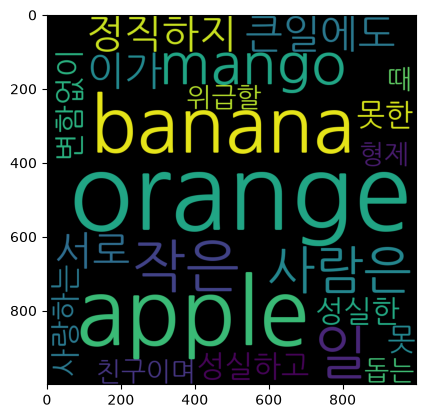

In [15]:
# DataFrame의 빈도 열을 {단어: 빈도} 딕셔너리로 변환합니다.
# generate_from_frequencies()는 계산된 빈도를 그대로 사용해 자주 나온 단어를 크게 표시합니다.
import matplotlib.pyplot as plt
from wordcloud import WordCloud

word_freq=wcdf1['freq'].to_dict()
wordcloud=WordCloud(font_path = fontpath, 
                    width = 1000, 
                    height = 1000).generate_from_frequencies(word_freq)
plt.imshow(wordcloud)
plt.show()

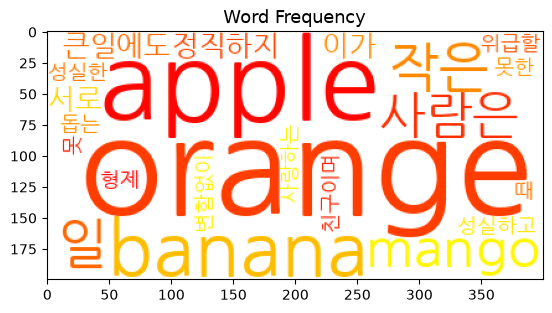

In [16]:
# 배경을 흰색으로 바꾸고 autumn 색상표를 적용한 워드클라우드입니다.
# colormap은 단어에 사용할 색상 계열을 지정합니다.
wordcloud=WordCloud(font_path = fontpath, 
                    background_color = 'white', 
                    colormap = 'autumn').generate_from_frequencies(word_freq)
plt.imshow(wordcloud)
plt.title('Word Frequency', size=13) # 제목 지정
plt.show()

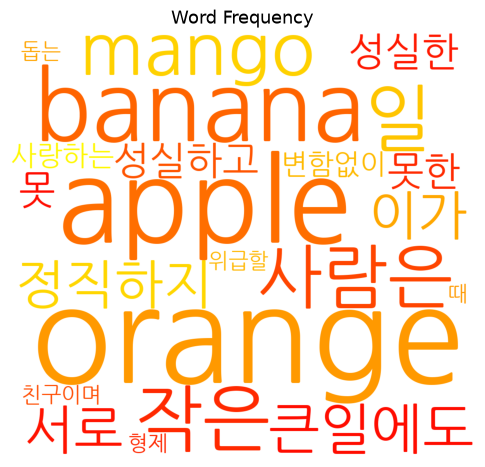

In [17]:
# 하트 이미지를 NumPy 배열로 바꾸어 워드클라우드의 배치 영역(mask)으로 사용합니다.
# random_state를 고정하면 다시 실행해도 단어 배치가 동일하게 재현됩니다.
from PIL import Image
import numpy as np
# 이미지 파일 읽어오기 및 RGB로 변환
im = Image.open('images/heart.png').convert("RGBA")
mask_arr = np.array(im)
mask_arr=np.array(im) # 픽셀 값 배열 형태 변환
wordcloud=WordCloud(font_path = fontpath, 
                    background_color = 'white', 
                    colormap = 'autumn',
                    width = 700,height = 700,
                    random_state = 43,
                    mask = mask_arr,prefer_horizontal=True).generate_from_frequencies(word_freq)
plt.figure(figsize=(6, 6))
plt.imshow(wordcloud)
plt.title('Word Frequency', size=13)
plt.axis('off')
plt.show()

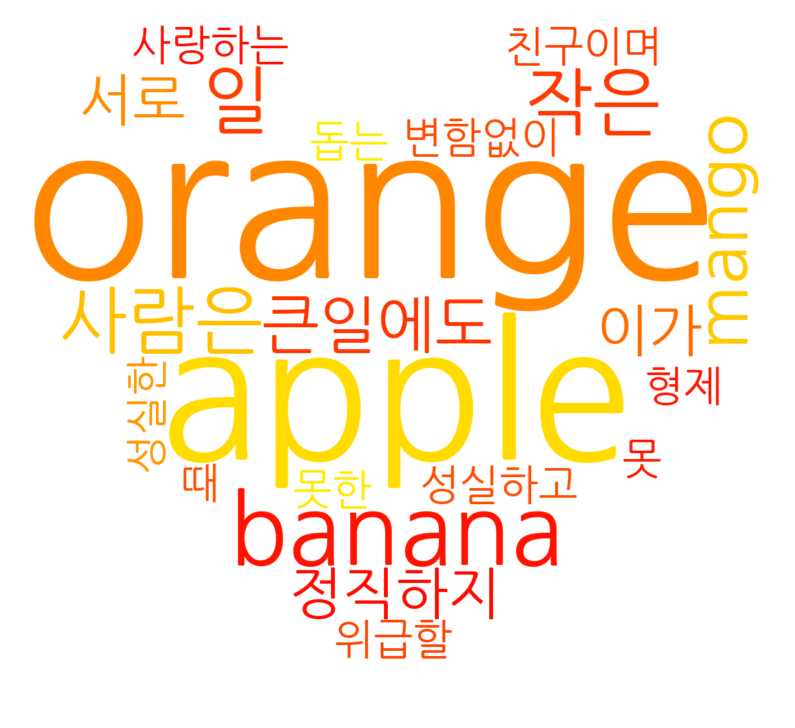

In [18]:
# 투명 배경이 있는 하트 이미지를 흰 RGB 배경에 합성해 마스크를 명확히 만듭니다.
# 완성된 PIL 이미지를 NumPy 배열로 변환한 뒤 WordCloud의 mask에 전달합니다.
from PIL import Image
# 이미지 형식을 RGBA (Red, Green, Blue, Alpha)로 변환
icon = Image.open('./images/heart.png').convert("RGBA")

# icon 이미지와 동일한 크기의 새로운 RGB 이미지를 생성하고, 배경색을 흰색으로 설정
mask = Image.new("RGB", icon.size, (255,255,255))

# 원본 아이콘 이미지를 마스크 이미지에 붙여넣음
# icon 이미지가 가진 알파 채널(투명도) 정보가 활용되어,
# 투명한 부분은 마스크의 배경색(여기서는 흰색)으로 유지되고,
# 불투명한 부분은 아이콘의 색상으로 채워짐
mask.paste(icon,icon) 
mask = np.array(mask)

wordcloud=WordCloud(font_path = fontpath,   # 사용할 글꼴 파일의 경로를 지정
                    background_color = 'white',            # 워드 클라우드의 배경색을 흰색으로 설정
                    colormap = 'autumn',                   # 워드 클라우드에 표시될 단어들의 색상 맵을 'autumn'으로 설정
                    width = 700,                          
                    height = 700,
                    # random_state = 43,                     # 워드 클라우드의 생성 과정에서 무작위성을 제어하기 위한 시드 값을 설정
                    mask = mask                            # 워드 클라우드의 모양을 mask 배열에 따라 만듬
                   ).generate_from_frequencies(word_freq)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 핵심 정리

- `glob`으로 여러 텍스트 파일을 찾고, 각 파일의 단어를 하나의 리스트로 모았습니다.
- `Counter`로 단어 빈도를 계산한 뒤 DataFrame과 딕셔너리 형태로 변환했습니다.
- `WordCloud.generate_from_frequencies()`로 빈도 기반 워드클라우드를 만들었습니다.
- `background_color`, `colormap`, `mask`, `random_state`로 모양과 색상 및 재현성을 조절했습니다.
- 단순한 `strip()` 정제는 한계가 있으므로, 실제 한국어 문서에는 형태소 분석기를 고려합니다.